Importer les bibliothèques nécessaires.
Charger les images du dataset et vérifier leurs extensions (jpeg, jpg, bmp, png). Supprimer celles qui ne correspondent pas.

In [4]:
# ! pip install torch
! pip install torchvision


   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 1.3 MB/s eta 0:00:03
   ------- -------------------------------- 0.8/4.3 MB 1.3 MB/s eta 0:00:03
   --------- ------------------------------ 1.0/4.3 MB 1.3 MB/s eta 0:00:03
   ------------ --------------------------- 1.3/4.3 MB 1.3 MB/s eta 0:00:03
   ----------------- ---------------------- 1.8/4.3 MB 1.3 MB/s eta 0:00:02
   ------------------- -------------------- 2.1/4.3 MB 1.3 MB/s eta 0:00:02
   --------------------- ------------------ 2.4/4.3 MB 1.3 MB/s eta 0:00:02
   ------------------------ --------------- 2.6/4.3 MB 1.3 MB/s eta 0:00:02
   -------------------------- ------------- 2.9/4.3 MB 1.3 MB/s eta 0:00:02
   ----------------------------- ---------- 3.1/4.3 MB 1.3 MB/s eta 0:00:01
   ------------------------------

In [5]:
import os
from PIL import Image
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [ ]:
dataset_path = "../data/Blood_Cells_Cancer"
valid_extensions = ('.jpeg', '.jpg', '.bmp', '.png')

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        file_path = os.path.join(root, file)
        if not file.lower().endswith(valid_extensions):
            os.remove(file_path)
        else:
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError):
                os.remove(file_path)

transforms.Resize((224, 224))
Rdimensionne toutes les images à 224x224 pixels.
Cela garantit que toutes les images ont la même taille, ce qui est nécessaire pour les réseaux de neurones.
transforms.ToTensor()
Convertit l’image PIL ou NumPy en tensor PyTorch.
Normalise aussi les valeurs de pixels de [0, 255] à [0.0, 1.0].
La forme du tensor devient (canaux, hauteur, largeur) au lieu de (hauteur, largeur, canaux).

_________________________________
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
Charge toutes les images depuis le dossier dataset_path.
Chaque sous-dossier est considéré comme une classe.
Applique automatiquement le transform défini (Resize + ToTensor) à chaque image.
loader = DataLoader(dataset, batch_size=32, shuffle=True)
Crée un itérateur pour parcourir le dataset par lots (batches) de 32 images.
Mélange les images à chaque époque (shuffle=True) pour éviter que l’ordre des données n’influence l’entraînement.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

classes = dataset.classes
print("Classes :", classes)



Classes : ['Benign', 'Pre-B', 'Pro-B', 'early Pre-B']


0

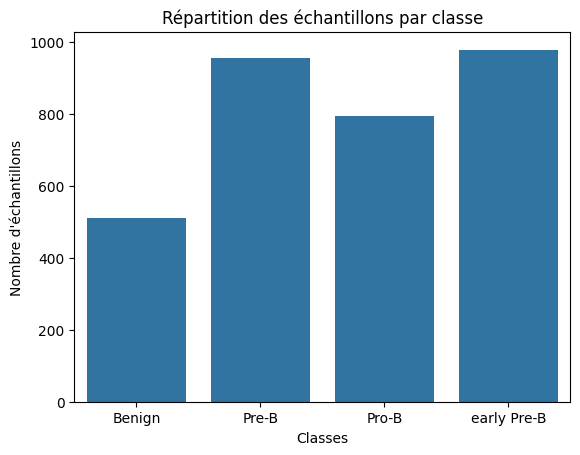

In [13]:
class_counts = [0]*len(classes)
for _, label in dataset:
    class_counts[label] += 1

sns.barplot(x=classes, y=class_counts)
plt.xlabel("Classes")
plt.ylabel("Nombre d'échantillons")
plt.title("Répartition des échantillons par classe")
plt.show()


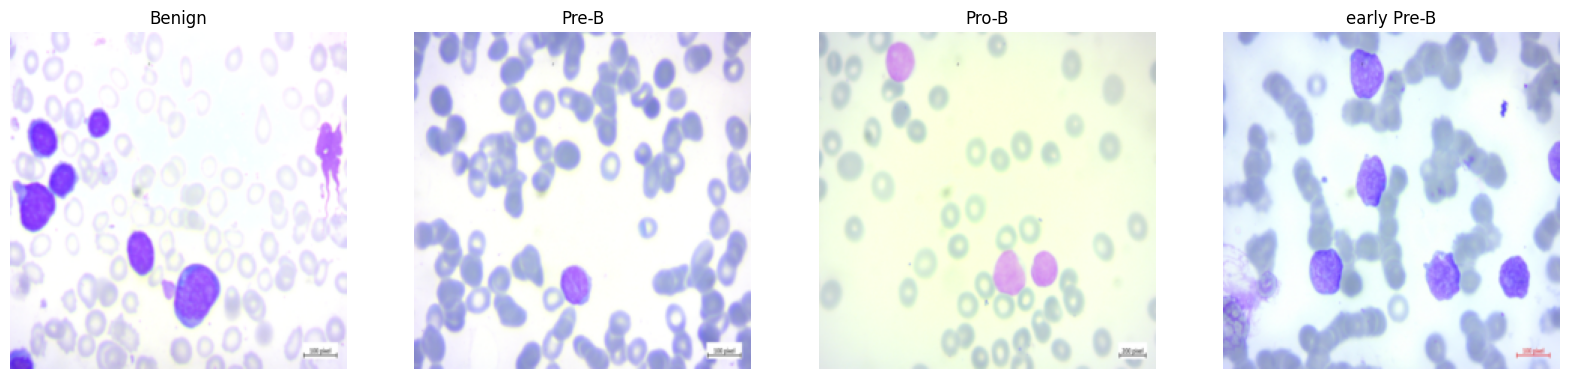

In [14]:
fig, axes = plt.subplots(1, len(classes), figsize=(5*len(classes), 5))
if len(classes) == 1:
    axes = [axes]

for idx, class_name in enumerate(classes):
    class_idx = dataset.class_to_idx[class_name]
    for img, label in dataset:
        if label == class_idx:
            image = img.permute(1, 2, 0).numpy()
            axes[idx].imshow(image)
            axes[idx].set_title(class_name)
            axes[idx].axis("off")
            break

plt.show()


In [15]:
import os
import shutil
import random

output_path  = r"../data/Blood_Cells_Cancer_Split"

os.makedirs(output_path, exist_ok=True)
splits = ['Train', 'Validation', 'Test']

for split in splits:
    os.makedirs(os.path.join(output_path, split), exist_ok=True)

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_folder):
        continue

    images = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpeg', '.jpg', '.bmp', '.png'))]
    random.shuffle(images)

    n_total = len(images)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)

    train_imgs = images[:n_train]
    val_imgs = images[n_train:n_train + n_val]
    test_imgs = images[n_train + n_val:]

    for split_name, split_imgs in zip(splits, [train_imgs, val_imgs, test_imgs]):
        split_class_folder = os.path.join(output_path, split_name, class_name)
        os.makedirs(split_class_folder, exist_ok=True)
        for img in split_imgs:
            src = os.path.join(class_folder, img)
            dst = os.path.join(split_class_folder, img)
            shutil.copy2(src, dst)


In [16]:

for split in splits:
    print(f"\n{split} :")
    split_path = os.path.join(output_path, split)
    for class_name in os.listdir(split_path):
        class_folder = os.path.join(split_path, class_name)
        if os.path.isdir(class_folder):
            count = len([f for f in os.listdir(class_folder) if f.lower().endswith(('.jpeg', '.jpg', '.bmp', '.png'))])
            print(f"  {class_name}: {count} images")



Train :
  Benign: 358 images
  early Pre-B: 685 images
  Pre-B: 668 images
  Pro-B: 557 images

Validation :
  Benign: 76 images
  early Pre-B: 146 images
  Pre-B: 143 images
  Pro-B: 119 images

Test :
  Benign: 78 images
  early Pre-B: 148 images
  Pre-B: 144 images
  Pro-B: 120 images
